In [56]:
import numpy as np 
import matplotlib.pyplot as plt 
import h5py as h5
import sys
import glob
import seaborn as sns
from scipy.optimize import curve_fit

#if necessary adjust the path from where to load stuff, but they should mostly live in the same dir:
sys.path.append("lib")
sys.path.append("../make_plots/")

import plot_utils

from POCAMSiPMHandler import breakdown_func, baseline, ampl

from pcm_monitoring_func import decode_value, get_timestamps, getADCreadings, extract_per_pwm, convert_to_perTrig, get_SiPM_dt



In [2]:
sns.set_palette('colorblind')

In [3]:
hem = '03'
pocam = '002'

batch = 'batch2'

T= 0

f_ = h5.File(f"/home/ecp/disk1/pocam_data/{batch}/prod_characterization_{hem}/Self_Monitoring_data_{T}C.h5")

In [4]:
all_data = {}
for sipm_pwm_ in f_['metadata/sipm_pwm']:
    all_data[sipm_pwm_]= {}
    for flm_ in f_['metadata']['flasher_modes']:
        all_data[sipm_pwm_][flm_.decode()] = extract_per_pwm(f_['flashes/{:d}/{:s}'.format(sipm_pwm_, flm_.decode())])

In [5]:
data_dict = {}


for flasher in ['lmg0', 'lmg1', 'lmg2', 'lmg3', 'kapu0', 'kapu3']:
    data_dict[flasher] = {}
    data_dict[flasher]["sipm_data"] = {}
    data_dict[flasher]["pd_data"] = {}
    
    lmg1_app = '_A'
    
    for sipm_pwm_ in f_['metadata']['sipm_pwm'][()]:#[:2]: 
        if not 'lmg1' in flasher:
            flasher_pd = flasher
        elif 'lmg1' in flasher:
            flasher_pd = flasher + lmg1_app#flasher_pd
        
        
        plotval = np.array([(all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['sum'].mean() - all_data[sipm_pwm_][flasher_pd][0]['adcA']['sum'].mean()) for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        data_dict[flasher]["pd_data"]['adcA'] = {}
        data_dict[flasher]["pd_data"]['adcA']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_mean'] = plotval
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        plotval = np.array([(all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['sum'].mean() - all_data[sipm_pwm_][flasher_pd][0]['adcB']['sum'].mean()) for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        
        data_dict[flasher]["pd_data"]['adcB'] = {}
        data_dict[flasher]["pd_data"]['adcB']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_mean'] = plotval
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        data_dict[flasher]["sipm_data"]['tdc2'] = {}
        data_dict[flasher]["sipm_data"]['tdc2']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["sipm_data"]['tdc2']['tdc2_peak_mean'] = plotval
        data_dict[flasher]["sipm_data"]['tdc2']['tdc2_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['tdc2_dt'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
    

In [6]:
filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/LMG405/photons_*_-40C_1-20.json'

filelist = glob.glob(filepath)


In [7]:
import json

In [8]:
pwm = []
val_pd = []
val_pmt = []
for file in filelist:
    with open(file, 'r') as f:
        data = json.load(f)
        pwm.append(data['meas_data'][0]['power'])
        val_pd.append(data['meas_data'][0]['value'])
        # val_pmt.append(data['meas_data'][1]['value'])

sorted_idx = np.argsort(pwm)
pwm  = np.array(pwm)[sorted_idx]
val_pd = np.array(val_pd)[sorted_idx]
# val_pmt = np.array(val_pmt)[sorted_idx]

In [9]:
emitters = [('lmg1','LMG365'),('lmg0','LMG405'), ('lmg3','LMG450'), ('lmg2','LMG520'), ('kapu0','KAPU405'), ('kapu3','KAPU465')]

In [10]:
hem = '03'
pocam = '002'

T= 25


In [11]:
filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/self_monitoring_{T}C.json'

with open(filepath, 'r') as f:
        data = json.load(f)

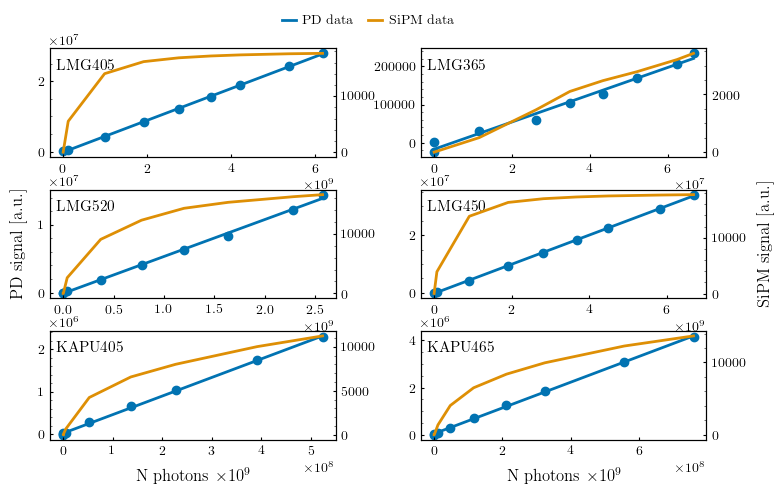

In [15]:
fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]

    filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/self_monitoring_{T}C.json'

    with open(filepath, 'r') as f:
        data = json.load(f)


    ax.scatter(data[dev_name]['N_photons_pd'], data[dev_name]['val_adcA'], color = 'C0' )
    y = np.array(data[dev_name]['N_photons_pd'])*data[dev_name]['adcA_slope'] + data[dev_name]['adcA_intercept']
    ax.plot(data[dev_name]['N_photons_pd'], y , color = 'C0' )
    ax.text(0.02,0.8, dev_name, transform=ax.transAxes, size = 11)
    if i == 4 or i == 5:
        ax.set_xlabel(r"N photons $\times 10^9$")
    if i ==2:
        ax.set_ylabel("PD signal [a.u.]")

    # #sipm data
    # mask = np.isin(data_dict[dev_sm]['sipm_data']['tdc2']['flasher_pwm'], pwm)
    ax1 = ax.twinx()
    ax1.plot(data[dev_name]['N_photons_pd'], data[dev_name]['val_tdc2'], color = 'C1' )
    if i ==3:
        ax1.set_ylabel("SiPM signal [a.u.]")

plt.subplots_adjust(hspace=0.3, wspace=0.3)

# legend with manual handles, centered on top
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color='C0', label='PD data'),
    Line2D([0], [0], color='C1', label='SiPM data'),
]
fig.legend(handles=handles, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 0.97), frameon=False, columnspacing=1)

plt.savefig(f'../make_plots/plots/png/self_monitoring_hem{hem}_T{T}C.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../make_plots/plots/pdf/self_monitoring_hem{hem}_T{T}C.pdf', dpi=300, bbox_inches='tight')


In [45]:
path_test_sm = f'../output/batch2/pocam_*/hem_*/self_monitoring_{T}C.json'

In [46]:
with open('../output/batch2/pocam_002/hem_03/self_monitoring_0C.json', 'r') as f:
    data = json.load(f)

In [53]:
data['LMG405'].keys()

dict_keys(['pwm', 'N_photons_pd', 'val_adcA', 'adcA_slope', 'adcA_intercept', 'adcA_slope_err', 'adcA_intercept_err', 'val_tdc2', 'tdc2_max-min', 'sipm_spline_fit_x', 'sipm_spline_fit_y', 'spline_ref_value'])

In [60]:
def linear(x,a,b):
    return a*x + b

In [61]:
slopes = {}
dyn_ranges = {}
for T in [-40, -30, -20,-10, 0, 25]:
    slopes[f'{T}C'] = {}
    dyn_ranges[f'{T}C'] = {}
    for emitter in ['LMG405', 'LMG365', 'LMG520', 'LMG450', 'KAPU405', 'KAPU465']:
        slopes[f'{T}C'][emitter] = {}
        slopes[f'{T}C'][emitter]['slope'] = []
        slopes[f'{T}C'][emitter]['slope_err'] = []
        slopes[f'{T}C'][emitter]['intercept'] = []
        slopes[f'{T}C'][emitter]['intercept_err'] = []
        slopes[f'{T}C'][emitter]['covariance'] = []
        dyn_ranges[f'{T}C'][emitter] = []
    path_test_sm = f'../output/batch2/pocam_*/hem_*/self_monitoring_{T}C.json'
    filelist = glob.glob(path_test_sm)
    print(len(filelist))
    for f in filelist:
            with open(f, 'r') as file:
                data = json.load(file)
            for emitter in ['LMG405', 'LMG365', 'LMG520', 'LMG450', 'KAPU405', 'KAPU465']:
                
                #also save covariance just by fitting the data
                popt_pd, pcov_pd = curve_fit(linear, data[emitter]['N_photons_pd'], data[emitter]['val_adcA'])
                slopes[f'{T}C'][emitter]['slope'].append(popt_pd[0])
                slopes[f'{T}C'][emitter]['slope_err'].append(np.sqrt(pcov_pd[0,0]))
                slopes[f'{T}C'][emitter]['intercept'].append(popt_pd[1])
                slopes[f'{T}C'][emitter]['intercept_err'].append(np.sqrt(pcov_pd[1,1]))
                slopes[f'{T}C'][emitter]['covariance'].append(pcov_pd[0,1])
                try:
                    dyn_ranges[f'{T}C'][emitter].append(data[emitter]['tdc2_max-min'])
                except:
                    dyn_ranges[f'{T}C'][emitter].append(np.nan) 
            
            
                

40
40
40
40


/home/ecp/virtual_environment/myenv/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


40
19


In [18]:
slopes['-40C']['LMG405'].keys()

dict_keys(['slope', 'slope_err', 'intercept', 'intercept_err'])

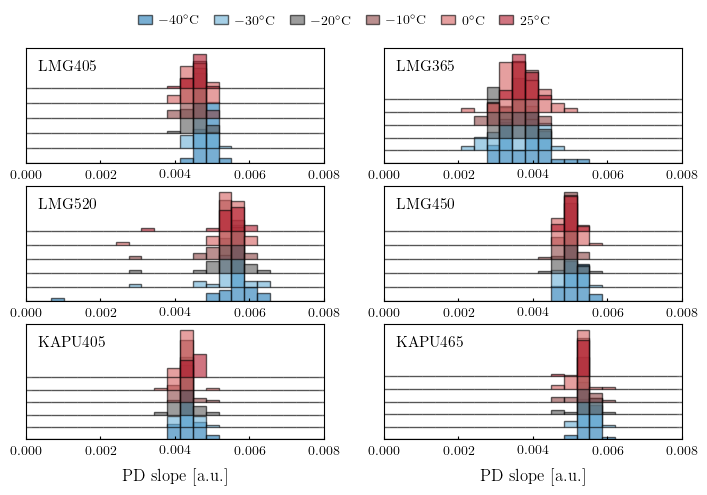

In [20]:
colors = [
    '#1f78b4',  # deep blue       → -40°C
    '#6aafd6',  # light blue      → -25°C
    '#5a5a5a',  # dark grey       → -10°C
    '#8c4444',  # dark muted red  →   5°C
    '#d45f5f',  # medium red      →  15°C
    '#b2182b',  # deep red        →  25°C
]

fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

temperatures = [-40, -30, -20, -10, 0, 25]
bins = np.linspace(0, 0.01, 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]

    # compute all histograms first to set the offset step
    counts_list = []
    for T in temperatures:
        counts, _ = np.histogram(slopes[f'{T}C'][dev_name]['slope'], bins=bins)
        counts_list.append(counts)

    # small step relative to peak height → partial overlap, not full stacking
    y_step = 0.2 * max(c.max() for c in counts_list)

    for j, (T, counts) in enumerate(zip(temperatures, counts_list)):
        offset = j * y_step  # coldest at bottom, warmest on top
        color = colors[j]

        ax.bar(bin_centers, counts, width=bin_width, bottom=offset,
               color=color, alpha=0.6, edgecolor='k', linewidth=1,
               zorder=j, label=f'${T}^\\circ$C')
        ax.axhline(offset, color='k', lw=0.4, alpha=0.3,
                   xmin=0.02, xmax=0.98, zorder=0)

    ax.set_xlim(0, 0.008)
    ax.set_yticks([])
    ax.text(0.04,0.8, dev_name, transform=ax.transAxes, size = 11)
    if i == 0:
        ax.legend(bbox_to_anchor=(1.8, 1.4), ncol=6, frameon=False, columnspacing=1, fontsize=10)

    if i == 4 or i == 5:
        ax.set_xlabel("PD slope [a.u.]")

plt.savefig('../make_plots/plots/png/self_monitoring_total_PD.png', dpi=300, bbox_inches='tight')
plt.savefig('../make_plots/plots/pdf/self_monitoring_total_PD.pdf', dpi=300, bbox_inches='tight')

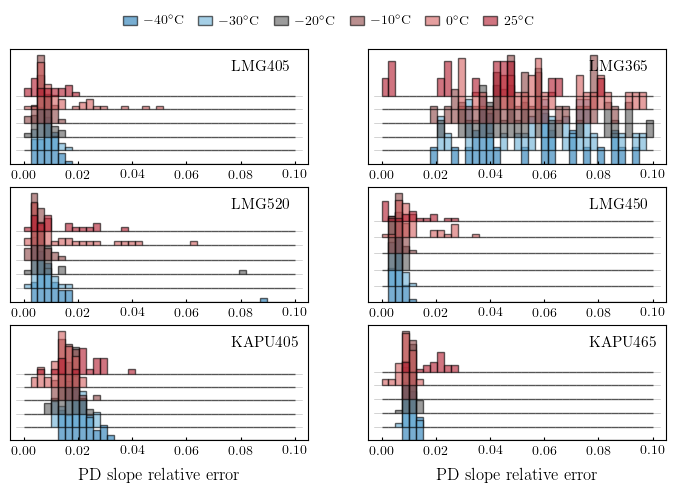

In [21]:
colors = [
    '#1f78b4',  # deep blue       → -40°C
    '#6aafd6',  # light blue      → -25°C
    '#5a5a5a',  # dark grey       → -10°C
    '#8c4444',  # dark muted red  →   5°C
    '#d45f5f',  # medium red      →  15°C
    '#b2182b',  # deep red        →  25°C
]

fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

temperatures = [-40, -30, -20, -10, 0, 25]
bins = np.linspace(0, 0.1, 40)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]

    # compute all histograms first to set the offset step
    counts_list = []
    for T in temperatures:
        rel_errors = np.array(slopes[f'{T}C'][dev_name]['slope_err']) / np.array(slopes[f'{T}C'][dev_name]['slope'])
        counts, _ = np.histogram(rel_errors, bins=bins)
        counts_list.append(counts)

    # small step relative to peak height → partial overlap, not full stacking
    y_step = 0.2 * max(c.max() for c in counts_list)

    for j, (T, counts) in enumerate(zip(temperatures, counts_list)):
        offset = j * y_step  # coldest at bottom, warmest on top
        color = colors[j]

        ax.bar(bin_centers, counts, width=bin_width, bottom=offset,
               color=color, alpha=0.6, edgecolor='k', linewidth=1,
               zorder=j, label=f'${T}^\\circ$C')
        ax.axhline(offset, color='k', lw=0.4, alpha=0.3,
                   xmin=0.02, xmax=0.98, zorder=0)

    # ax.set_xlim(0, 0.05)
    ax.set_yticks([])
    ax.text(0.74,0.8, dev_name, transform=ax.transAxes, size = 11)
    if i == 0:
        ax.legend(bbox_to_anchor=(1.8, 1.4), ncol=6, frameon=False, columnspacing=1, fontsize=10)

    if i == 4 or i == 5:
        ax.set_xlabel("PD slope relative error")

plt.savefig('../make_plots/plots/png/self_monitoring_cal_test.png', dpi=300, bbox_inches='tight')
plt.savefig('../make_plots/plots/pdf/self_monitoring_cal_test.pdf', dpi=300, bbox_inches='tight')

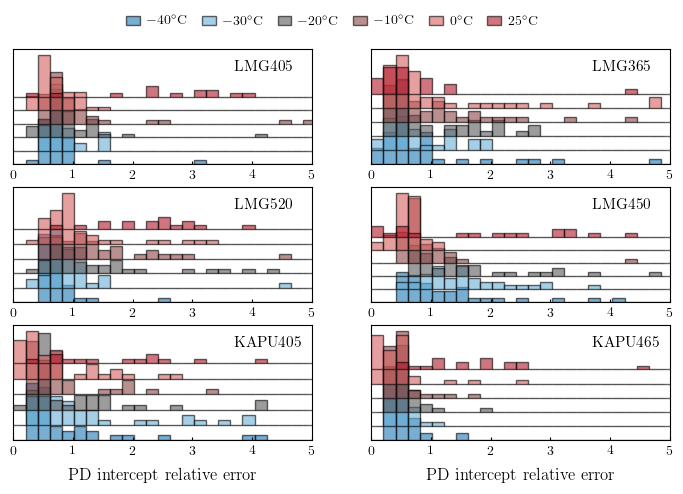

In [22]:
colors = [
    '#1f78b4',  # deep blue       → -40°C
    '#6aafd6',  # light blue      → -25°C
    '#5a5a5a',  # dark grey       → -10°C
    '#8c4444',  # dark muted red  →   5°C
    '#d45f5f',  # medium red      →  15°C
    '#b2182b',  # deep red        →  25°C
]

fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

temperatures = [-40, -30, -20, -10, 0, 25]
bins = np.linspace(0, 20, 100)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]

    # compute all histograms first to set the offset step
    counts_list = []
    for T in temperatures:
        rel_errors = np.array(slopes[f'{T}C'][dev_name]['intercept_err']) / np.array(slopes[f'{T}C'][dev_name]['intercept'])
        counts, _ = np.histogram(np.absolute(rel_errors), bins=bins)
        counts_list.append(counts)

    # small step relative to peak height → partial overlap, not full stacking
    y_step = 0.2 * max(c.max() for c in counts_list)

    for j, (T, counts) in enumerate(zip(temperatures, counts_list)):
        offset = j * y_step  # coldest at bottom, warmest on top
        color = colors[j]

        ax.bar(bin_centers, counts, width=bin_width, bottom=offset,
               color=color, alpha=0.6, edgecolor='k', linewidth=1,
               zorder=j, label=f'${T}^\\circ$C')
        ax.axhline(offset, color='k', lw=0.4, alpha=0.3,
                   xmin=0.02, xmax=0.98, zorder=0)

    ax.set_xlim(0, 5)
    ax.set_yticks([])
    ax.text(0.74,0.8, dev_name, transform=ax.transAxes, size = 11)
    if i == 0:
        ax.legend(bbox_to_anchor=(1.8, 1.4), ncol=6, frameon=False, columnspacing=1, fontsize=10)

    if i == 4 or i == 5:
        ax.set_xlabel("PD intercept relative error")

plt.savefig('../make_plots/plots/png/self_monitoring_cal_test_intercept.png', dpi=300, bbox_inches='tight')
plt.savefig('../make_plots/plots/pdf/self_monitoring_cal_test_intercept.pdf', dpi=300, bbox_inches='tight')

/tmp/ipykernel_2821/3972921696.py:45: RuntimeWarning: invalid value encountered in sqrt
  signal_error = np.sqrt(


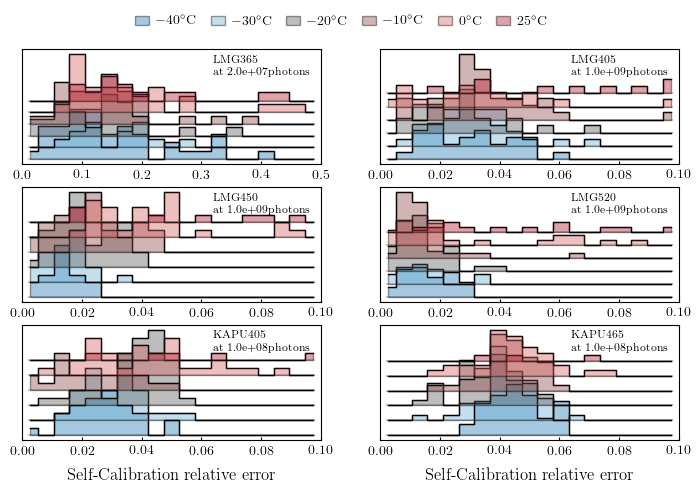

In [63]:
colors = [
    '#1f78b4',  # deep blue       → -40°C
    '#6aafd6',  # light blue      → -25°C
    '#5a5a5a',  # dark grey       → -10°C
    '#8c4444',  # dark muted red  →   5°C
    '#d45f5f',  # medium red      →  15°C
    '#b2182b',  # deep red        →  25°C
]

ref_photons = {
    'LMG365': 2.0e7,
    'LMG405': 1.0e9,
    'LMG450': 1.0e9,
    'LMG520': 1.0e9,
    'KAPU405': 1.0e8,
    'KAPU465': 1.0e8,
}

fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

temperatures = [-40, -30, -20, -10, 0, 25]


for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]
    bins = np.linspace(0, 0.1, 20)
    if dev_name == 'LMG365':
        bins = np.linspace(0, 0.5, 20)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]

    # compute all histograms first to set the offset step
    counts_list = []
    for T in temperatures:
        slope_arr = np.array(slopes[f'{T}C'][dev_name]['slope'])
        intercept_arr = np.array(slopes[f'{T}C'][dev_name]['intercept'])
        slope_err_arr = np.array(slopes[f'{T}C'][dev_name]['slope_err'])
        intercept_err_arr = np.array(slopes[f'{T}C'][dev_name]['intercept_err'])
        cov_si_arr = np.array(slopes[f'{T}C'][dev_name]['covariance'])  # off-diagonal of pcov

        estimated_signal = slope_arr * ref_photons[dev_name] + intercept_arr
        signal_error = np.sqrt(
            (slope_err_arr * ref_photons[dev_name])**2
            + intercept_err_arr**2
            + 2 * ref_photons[dev_name] * cov_si_arr
        )

        median_pd = np.median(estimated_signal)

        estimated_nphotons = (estimated_signal - intercept_arr) / slope_arr

        photons_error = np.sqrt(
            signal_error**2
            + intercept_err_arr**2
            + (estimated_nphotons**2) * slope_err_arr**2
            + 2 * estimated_nphotons * cov_si_arr
        ) / np.abs(slope_arr)
        rel_errors = photons_error / ref_photons[dev_name]
        counts, _ = np.histogram(np.absolute(rel_errors), bins=bins)
        counts_list.append(counts)

    # small step relative to peak height → partial overlap, not full stacking
    y_step = 0.2 * max(c.max() for c in counts_list)

    for j, (T, counts) in enumerate(zip(temperatures, counts_list)):
        offset = j * y_step  # coldest at bottom, warmest on top
        color = colors[j]

        # ax.bar(bin_centers, counts, width=bin_width, bottom=offset,
        #        color=color, alpha=0.6, edgecolor='k', linewidth=1,
        #        zorder=j, label=f'${T}^\\circ$C')
        ax.step(bin_centers, counts + offset, where='mid', color='k', linewidth=1)
        ax.fill_between(bin_centers, offset, counts + offset, step='mid', color=color, alpha=0.4, edgecolor='k',
                        zorder=j, label=f'${T}^\\circ$C')
        ax.axhline(offset, color='k', lw=0.3,
                   xmin=0.02, xmax=0.98, zorder=0)

    ax.set_xlim(0, 0.1)
    if dev_name == 'LMG365':
        ax.set_xlim(0, 0.5)
    ax.set_yticks([])
    ax.text(0.64,0.78, f'{dev_name}\nat {ref_photons[dev_name]:.1e}photons', transform=ax.transAxes, size = 8)
    if i == 0:
        ax.legend(bbox_to_anchor=(1.8, 1.4), ncol=6, frameon=False, columnspacing=1, fontsize=10)

    if i == 4 or i == 5:
        ax.set_xlabel("Self-Calibration relative error")

plt.savefig('../make_plots/plots/png/self_calibration.png', dpi=300, bbox_inches='tight')
plt.savefig('../make_plots/plots/pdf/self_calibration.pdf', dpi=300, bbox_inches='tight')

In [22]:
path_test_sm = f'../output/batch2/pocam_*/hem_*/LMG405/self_monitoring_*C.json'

In [23]:
glob.glob(path_test_sm)

['../output/batch2/pocam_009/hem_14/LMG405/self_monitoring_0C.json',
 '../output/batch2/pocam_009/hem_15/LMG405/self_monitoring_0C.json',
 '../output/batch2/pocam_002/hem_04/LMG405/self_monitoring_-30C.json',
 '../output/batch2/pocam_002/hem_04/LMG405/self_monitoring_-20C.json',
 '../output/batch2/pocam_002/hem_04/LMG405/self_monitoring_-10C.json',
 '../output/batch2/pocam_002/hem_04/LMG405/self_monitoring_0C.json',
 '../output/batch2/pocam_002/hem_03/LMG405/self_monitoring_-30C.json',
 '../output/batch2/pocam_002/hem_03/LMG405/self_monitoring_-20C.json',
 '../output/batch2/pocam_002/hem_03/LMG405/self_monitoring_-10C.json',
 '../output/batch2/pocam_002/hem_03/LMG405/self_monitoring_-40C.json',
 '../output/batch2/pocam_002/hem_03/LMG405/self_monitoring_0C.json',
 '../output/batch2/pocam_002/hem_03/LMG405/self_monitoring_25C.json',
 '../output/batch2/pocam_004/hem_05/LMG405/self_monitoring_0C.json',
 '../output/batch2/pocam_004/hem_06/LMG405/self_monitoring_0C.json']

In [41]:
with open('../output/batch2/pocam_002/hem_03/KAPU405/self_monitoring_0C.json', 'r') as f:
    data = json.load(f)

In [42]:
data['meas_data']

[{'data_format': 'fit_linear',
  'label': 'PD_vs_power',
  'title': 'PD signal vs. flasher power — linear fit',
  'power': [7500, 10000, 15000, 20000, 25000, 30000, 35000, 45000, 54000],
  'value': [-2387.610000014305,
   -12136.780000001192,
   -2728.1299999952316,
   43389.1099999845,
   248578.69999998808,
   523144.8899999857,
   798938.0300000012,
   1305506.7800000012,
   1724713.4900000095],
  'slope': 0.004441548758701088,
  'intercept': 21083.131166513944,
  'slope_error': 6.93856516466884e-05,
  'intercept_error': 12165.645724872942,
  'covariance': [[4.814368654435594e-09, -0.5344145415473202],
   [-0.5344145415473202, 148002935.9031193]],
  'temperature': 0},
 {'data_format': 'fit_spline_isotonic',
  'label': 'SiPM_vs_power',
  'title': 'SiPM signal vs. abs-cal PD value — spline + isotonic fit',
  'power': [7500, 10000, 15000, 20000, 25000, 30000, 35000, 45000, 54000],
  'val_pd': [0.0,
   0.0,
   159544.68,
   994274.43,
   41632128.85,
   106993756.39,
   171627051.15,
  